# Portfolio construction

Portfolio choice is an estimation problem wearing an optimisation costume. Markowitz tells you to trade
mean against variance, but the means and the covariance are *estimated*, and the optimiser ruthlessly
exploits their errors -- it shorts the noise and concentrates on the lucky. The whole craft is therefore
about the **return model**: what distribution generated the returns, how do we estimate it without
overfitting, and how do we carry its uncertainty into the weights.

So we put a probability model at the centre and let `mixle` carry it. We fit the joint return
distribution (Gaussian, then heavy-tailed Student-t), estimate the covariance with **Ledoit-Wolf
shrinkage**, update beliefs the Bayesian way with a **conjugate posterior**, discover **regimes** with a
mixture, measure tail risk by **sampling the fitted model**, and propagate parameter uncertainty into the
efficient frontier with a **Normal-Inverse-Wishart posterior**. `scipy` appears only as the optimiser, fed
by mixle estimates.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import io
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kurtosis, chi2
from mixle.stats import MultivariateGaussianEstimator, MultivariateGaussianDistribution, MultivariateStudentTEstimator, MixtureEstimator, conjugate_posterior
from mixle.analysis import LedoitWolfEstimator
from mixle.inference import estimate
from mixle.inference.estimation import optimize

rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
rows = lambda R: [list(r) for r in np.asarray(R)]                      # mixle wants a sequence of vectors
def fit(R, est, its=1):                                                 # fit any mixle estimator on a return panel
    return optimize(rows(R), est, max_its=its, rng=np.random.RandomState(0), out=io.StringIO())

prices = pd.read_csv('../../data/stocks/prices.csv', index_col='date', parse_dates=True)
rets = np.log(prices).diff().dropna(); tickers = list(prices.columns); N = len(tickers); rf = 0.03; ann = 252
A = rets.values
print('%d assets, %d daily returns; annualised vols %s' % (N, len(rets), np.round(rets.std().values * np.sqrt(ann), 2)))

6 assets, 755 daily returns; annualised vols [0.21 0.16 0.3  0.24 0.19 0.13]


## 1. The return distribution is not Gaussian

The shipped price panel is geometric Brownian motion -- Gaussian by construction. Real markets are not: they
have **fat tails** (crashes are far more likely than a normal allows) and **volatility clustering** (calm
and turbulent periods persist). We build a realistic panel with both -- persistent calm/crisis regimes and
per-asset Student-t tails -- and use it for the rest of the notebook.

Then the first modelling decision: fit the joint return distribution with `mixle`. A multivariate
**Gaussian** versus a multivariate **Student-t**; the Student-t's fitted degrees of freedom are a direct
readout of tail fatness (low = fat), and its higher log-likelihood is the evidence that the Gaussian
understates risk.

fitted Student-t degrees of freedom: 5.0 (low => fat tails)
mean log-likelihood  Gaussian 15.24  vs  Student-t 15.64  (Student-t fits the tails better)


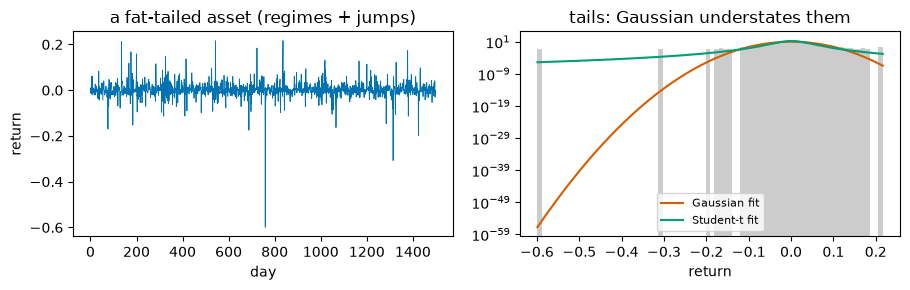

In [2]:
Td = 1500; df_i = np.array([3, 30, 30, 8, 30, 30])[:N]; vol_i = rets.std().values
eqcorr = lambda rho: rho * np.ones((N, N)) + (1 - rho) * np.eye(N)
calmC, crisisC = eqcorr(0.30), eqcorr(0.70); reg = np.zeros(Td, int)
for t in range(1, Td): reg[t] = rng.rand() < (0.06 if reg[t - 1] == 0 else 0.80)        # persistent regimes
Asim = np.zeros((Td, N))
for t in range(Td):
    C = crisisC if reg[t] else calmC; vsc = 2.5 if reg[t] else 1.0
    z = rng.multivariate_normal(np.zeros(N), C); g = np.sqrt(df_i / chi2.rvs(df_i, random_state=rng))
    Asim[t] = A.mean(0) + vol_i * vsc * z * g

# fit the joint distribution two ways through mixle
g_gauss = estimate(rows(Asim), MultivariateGaussianEstimator(dim=N))
g_t = fit(Asim, MultivariateStudentTEstimator(dim=N), its=60)
ll = lambda d: np.mean([d.log_density(r) for r in Asim[:400]])
print('fitted Student-t degrees of freedom: %.1f (low => fat tails)' % g_t.dof)
print('mean log-likelihood  Gaussian %.2f  vs  Student-t %.2f  (Student-t fits the tails better)' % (ll(g_gauss), ll(g_t)))

fig, ax = panel(2, 4.6, 3.0)
ax[0].plot(Asim[:, 0], lw=0.6, color='#0072B2'); ax[0].set(title='a fat-tailed asset (regimes + jumps)', xlabel='day', ylabel='return')
i = 0; xs = np.linspace(Asim[:, i].min(), Asim[:, i].max(), 200)
ax[1].hist(Asim[:, i], bins=80, density=True, color='#ccc')
from scipy.stats import norm, t as tdist
sd = np.sqrt(g_gauss.covar[i, i]); ax[1].plot(xs, norm.pdf(xs, g_gauss.mu[i], sd), color='#D55E00', label='Gaussian fit')
sc = np.sqrt(np.asarray(g_t.shape)[i, i]); ax[1].plot(xs, tdist.pdf(xs, g_t.dof, g_t.mu[i], sc), color='#009E73', label='Student-t fit')
ax[1].set(title='tails: Gaussian understates them', xlabel='return', yscale='log'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. The efficient frontier

With the mean vector and covariance in hand, Markowitz's frontier is the set of minimum-variance portfolios
for each target return. We get `mu` and `Sigma` from the mixle Gaussian fit and trace the frontier in closed
form. Every point is a fully-invested portfolio; the curve is the best risk-return trade-off achievable
from these estimates.

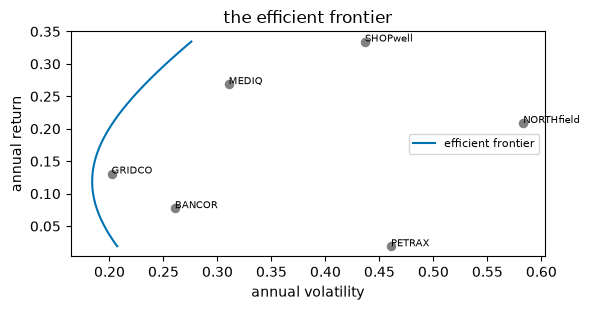

global minimum-variance vol = 18.4%


In [3]:
mu = np.asarray(g_gauss.mu) * ann; Sigma = np.asarray(g_gauss.covar) * ann
inv = np.linalg.inv(Sigma); one = np.ones(N)
a_, b_, c_ = one @ inv @ one, one @ inv @ mu, mu @ inv @ mu; det = a_ * c_ - b_ ** 2
def frontier_w(m): return inv @ (((c_ - b_ * m) / det) * one + ((a_ * m - b_) / det) * mu)
tgts = np.linspace(mu.min(), mu.max(), 40); fvol = np.array([np.sqrt(frontier_w(m) @ Sigma @ frontier_w(m)) for m in tgts])
sd = np.sqrt(np.diag(Sigma))
fig, ax = panel(1, 6, 3.2)
ax[0].plot(fvol, tgts, color='#0072B2', label='efficient frontier'); ax[0].scatter(sd, mu, c='gray', s=34)
for i, tk in enumerate(tickers): ax[0].annotate(tk, (sd[i], mu[i]), fontsize=7)
ax[0].set(xlabel='annual volatility', ylabel='annual return', title='the efficient frontier'); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('global minimum-variance vol = %.1f%%' % (100 * np.sqrt(1 / a_)))

## 3. Tangency, the capital market line, and the Sharpe ratio

Adding a risk-free asset, the best portfolio of risky assets is the **tangency** portfolio -- the one that
maximises the Sharpe ratio. Every investor holds it, levered up or down along the capital market line. Its
weights, derived from the same mixle-estimated `mu` and `Sigma`, already hint at the estimation-error
problem: they are extreme and include large shorts.

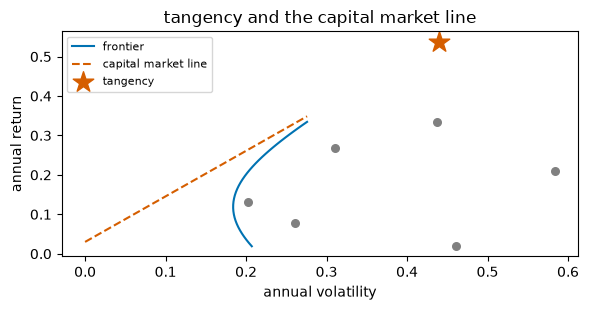

tangency Sharpe 1.15; weights {'NORTHfield': np.float64(-0.02), 'BANCOR': np.float64(-0.66), 'PETRAX': np.float64(-0.71), 'SHOPwell': np.float64(0.67), 'MEDIQ': np.float64(1.14), 'GRIDCO': np.float64(0.58)}
the weights short and concentrate -- a symptom of estimation error, addressed next


In [4]:
w_tan = inv @ (mu - rf * one); w_tan /= w_tan.sum()
sharpe = (w_tan @ mu - rf) / np.sqrt(w_tan @ Sigma @ w_tan)
fig, ax = panel(1, 6, 3.2)
ax[0].plot(fvol, tgts, color='#0072B2', label='frontier'); ax[0].scatter(sd, mu, c='gray', s=30)
cml = np.linspace(0, fvol.max(), 30); ax[0].plot(cml, rf + sharpe * cml, '--', color='#D55E00', label='capital market line')
ax[0].scatter([np.sqrt(w_tan @ Sigma @ w_tan)], [w_tan @ mu], marker='*', s=240, c='#D55E00', label='tangency')
ax[0].set(xlabel='annual volatility', ylabel='annual return', title='tangency and the capital market line'); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('tangency Sharpe %.2f; weights %s' % (sharpe, dict(zip(tickers, np.round(w_tan, 2)))))
print('the weights short and concentrate -- a symptom of estimation error, addressed next')

## 4. The estimation-error problem

The tangency portfolio is optimal *for the estimated parameters*. Estimate them on the first half of the
data and test on the second, and the supposedly-optimal portfolio is routinely beaten by naive 1/N: the
optimiser has fit noise. This is the central pathology, and the next three sections are its cures --
shrinkage, Bayesian priors, and constraints.

In [5]:
half = len(Asim) // 2
g1 = estimate(rows(Asim[:half]), MultivariateGaussianEstimator(dim=N))
mu1 = np.asarray(g1.mu) * ann; S1 = np.asarray(g1.covar) * ann
w_opt = np.linalg.solve(S1, mu1 - rf * one); w_opt /= w_opt.sum(); w_eq = one / N
oos = lambda w: (Asim[half:] @ w).mean() / (Asim[half:] @ w).std() * np.sqrt(ann)
print('out-of-sample Sharpe: in-sample tangency %.2f vs equal-weight 1/N %.2f' % (oos(w_opt), oos(w_eq)))
print('max |weight|: tangency %.0f%% vs 1/N %.0f%%' % (100 * np.abs(w_opt).max(), 100 * np.abs(w_eq).max()))

out-of-sample Sharpe: in-sample tangency -0.06 vs equal-weight 1/N 0.68
max |weight|: tangency 335% vs 1/N 17%


## 5. Covariance shrinkage with Ledoit-Wolf

The sample covariance is ill-conditioned when observations are not large relative to the number of assets:
its extreme eigenvalues are biased, and inverting it amplifies the error. **Ledoit-Wolf** shrinks the
sample covariance toward a well-conditioned target (a scaled identity) by a data-driven intensity. This is
a covariance *estimator*, so it belongs in the library: `mixle` provides `LedoitWolfEstimator`, a
drop-in `ParameterEstimator` that returns a Gaussian with the shrunk covariance and reports the intensity
it chose. On a short window it sharply lowers the condition number and **stabilises the resulting weights**
window-to-window -- the benefit that shows up as higher net Sharpe and lower turnover in the backtest
later. (The reduction in out-of-sample *volatility* grows with the number of assets; with only six it is
the conditioning and stability that pay off.)

on a 40-day window: Ledoit-Wolf shrinkage intensity delta = 0.28
covariance condition number: sample 29 -> shrunk 8 (better-conditioned to invert)
min-variance weight turnover window-to-window: sample 0.70 vs Ledoit-Wolf 0.42 (shrinkage stabilises the weights)


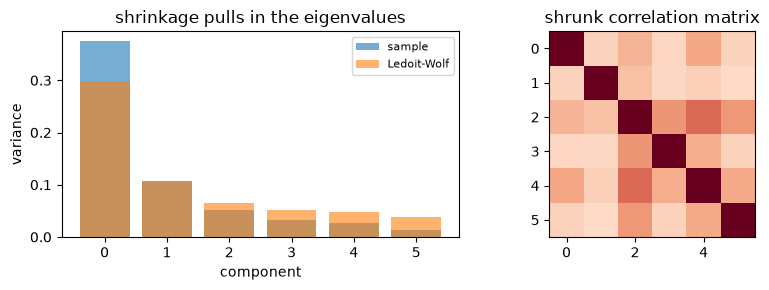

In [6]:
minvar = lambda S: (lambda w: w / w.sum())(np.linalg.solve(S, one))
win = 40                                                            # a short estimation window: covariance is ill-conditioned
g_s = estimate(rows(Asim[:win]), MultivariateGaussianEstimator(dim=N)); S_s = np.asarray(g_s.covar) * ann
g_lw = estimate(rows(Asim[:win]), LedoitWolfEstimator(dim=N)); S_lw = np.asarray(g_lw.covar) * ann   # mixle shrinkage estimator
print('on a %d-day window: Ledoit-Wolf shrinkage intensity delta = %.2f' % (win, g_lw.shrinkage))
print('covariance condition number: sample %.0f -> shrunk %.0f (better-conditioned to invert)' % (np.linalg.cond(S_s), np.linalg.cond(S_lw)))
def weight_turnover(cov_fn):                                        # how much min-variance weights swing window-to-window
    ws = [minvar(cov_fn(Asim[s - win:s])) for s in range(win, len(Asim) - 1, 20)]
    return np.mean([np.abs(ws[i] - ws[i - 1]).sum() for i in range(1, len(ws))])
print('min-variance weight turnover window-to-window: sample %.2f vs Ledoit-Wolf %.2f (shrinkage stabilises the weights)'
      % (weight_turnover(lambda R: np.asarray(estimate(rows(R), MultivariateGaussianEstimator(dim=N)).covar)),
         weight_turnover(lambda R: np.asarray(estimate(rows(R), LedoitWolfEstimator(dim=N)).covar))))

fig, ax = panel(2, 4.4, 3.0)
ax[0].bar(range(N), np.sort(np.linalg.eigvalsh(S_s))[::-1], alpha=0.6, label='sample')
ax[0].bar(range(N), np.sort(np.linalg.eigvalsh(S_lw))[::-1], alpha=0.6, label='Ledoit-Wolf')
ax[0].set(title='shrinkage pulls in the eigenvalues', xlabel='component', ylabel='variance'); ax[0].legend(fontsize=8)
ax[1].imshow(np.asarray(g_lw.covar) / np.outer(np.sqrt(np.diag(g_lw.covar)), np.sqrt(np.diag(g_lw.covar))), cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set(title='shrunk correlation matrix'); plt.tight_layout(); plt.show()

## 6. Bayesian returns: a conjugate posterior (and Black-Litterman)

Shrinkage of the *mean* is best understood as Bayesian updating. With a Normal-Inverse-Wishart prior over
`(mu, Sigma)`, the posterior is conjugate and closed-form -- `mixle`'s `conjugate_posterior` returns
it directly. Its mean estimate pulls the noisy sample mean toward the prior, its **posterior predictive**
is a Student-t (fatter than the plug-in Gaussian, because parameters are uncertain), and we can **sample**
whole `(mu, Sigma)` draws from it. **Black-Litterman** is exactly this idea with the prior set to
market-equilibrium returns and the data replaced by subjective views.

posterior-predictive distribution: MultivariateStudentTDistribution (parameter uncertainty -> fatter tails)
max |weight|: sample-mean tangency 114% vs Black-Litterman 62%


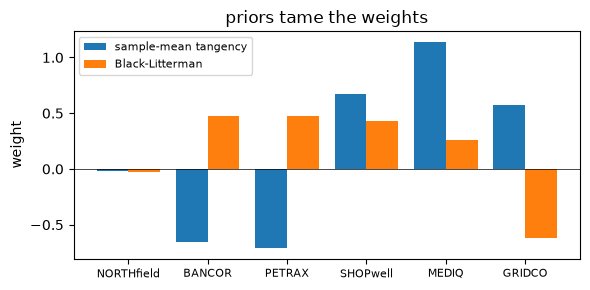

In [7]:
post = conjugate_posterior(MultivariateGaussianDistribution(np.zeros(N), np.cov(Asim.T)), rows(Asim))
pe = post.point_estimate()                                          # posterior-mean (mu, Sigma)
mu_post = np.asarray(pe.mu) * ann
# Black-Litterman: same conjugate machinery, prior centred on reverse-optimised equilibrium returns
mkt = Asim @ (one / N); delta = (mkt.mean() * ann - rf) / (mkt.var() * ann); Pi = delta * Sigma @ (one / N)
tau = 0.05; P = np.zeros((1, N)); P[0, 0] = 1; P[0, 1] = -1; Q = np.array([0.03]); Om = np.array([[0.0004]])
M = np.linalg.inv(np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Om) @ P)
mu_bl = M @ (np.linalg.inv(tau * Sigma) @ Pi + P.T @ np.linalg.inv(Om) @ Q)
w_bl = np.linalg.solve(Sigma, mu_bl - rf * one); w_bl /= w_bl.sum()
print('posterior-predictive distribution: %s (parameter uncertainty -> fatter tails)' % type(post.posterior_predictive()).__name__)
print('max |weight|: sample-mean tangency %.0f%% vs Black-Litterman %.0f%%' % (100 * np.abs(w_tan).max(), 100 * np.abs(w_bl).max()))
fig, ax = panel(1, 6, 3.0)
xx = np.arange(N); ax[0].bar(xx - 0.2, w_tan, 0.4, label='sample-mean tangency'); ax[0].bar(xx + 0.2, w_bl, 0.4, label='Black-Litterman')
ax[0].set_xticks(xx); ax[0].set_xticklabels(tickers, fontsize=8); ax[0].axhline(0, color='k', lw=0.5)
ax[0].set(ylabel='weight', title='priors tame the weights'); ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Downside risk: VaR and CVaR by sampling the model

Variance penalises upside and downside alike; investors care about the **downside**. Value-at-risk is a
loss quantile, and conditional VaR (expected shortfall) is the average loss beyond it. With a fat-tailed
return model these exceed the Gaussian values -- and the clean way to compute them is to **sample the
fitted mixle distribution** and read the tail off the draws. We then minimise CVaR directly (a convex
program) and compare to the minimum-variance portfolio.

daily 95% VaR / CVaR  min-variance: 1.69% / 2.45%   CVaR-optimal: 1.70% / 2.45%


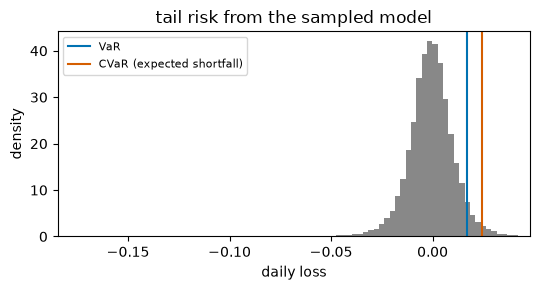

In [8]:
sim = np.asarray(g_t.sampler(seed=1).sample(40000))                 # draw 40k days from the fitted Student-t
al = 0.05
def cvar(w): L = -(sim @ w); v = np.quantile(L, 1 - al); return L[L >= v].mean()
def var_(w): return np.quantile(-(sim @ w), 1 - al)
res = minimize(cvar, one / N, bounds=[(0, 1)] * N,
               constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}], method='SLSQP')
w_cv = res.x; w_mv = minvar(np.asarray(g_t.covar) if hasattr(g_t, 'covar') else np.cov(Asim.T))
w_mv = np.clip(w_mv, 0, None); w_mv /= w_mv.sum()
print('daily 95%% VaR / CVaR  min-variance: %.2f%% / %.2f%%   CVaR-optimal: %.2f%% / %.2f%%'
      % (100 * var_(w_mv), 100 * cvar(w_mv), 100 * var_(w_cv), 100 * cvar(w_cv)))
fig, ax = panel(1, 5.5, 3.0)
L = -(sim @ w_cv); ax[0].hist(L, bins=120, color='#888', density=True)
ax[0].axvline(var_(w_cv), color='#0072B2', label='VaR'); ax[0].axvline(cvar(w_cv), color='#D55E00', label='CVaR (expected shortfall)')
ax[0].set(xlabel='daily loss', ylabel='density', title='tail risk from the sampled model', xlim=(L.min(), np.quantile(L, 0.999)))
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 8. Return regimes: a mixture model

Markets switch between calm and turbulent regimes, and correlations rise exactly when diversification is
most needed. A **mixture** of two joint Gaussians, fit with `mixle`'s `MixtureEstimator`, recovers
them: a high-weight calm component with low volatility and modest correlation, and a low-weight crisis
component with high volatility and high correlation. The posterior regime probability over time tracks the
turbulence we built in.

  calm   regime: weight 0.79  avg vol 23.1%  avg correlation 0.30
  crisis regime: weight 0.21  avg vol 67.7%  avg correlation 0.65


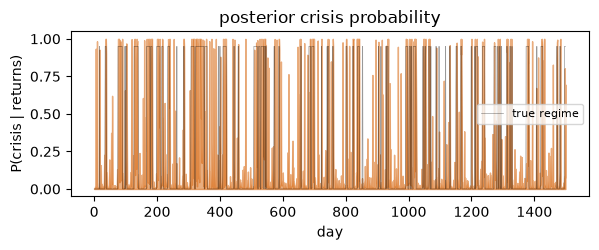

posterior crisis-probability correlation with the true regime: 0.67


In [9]:
mix = fit(Asim, MixtureEstimator([MultivariateGaussianEstimator(dim=N) for _ in range(2)]), its=80)
comps = sorted(zip(mix.w, mix.components), key=lambda kv: np.trace(np.asarray(kv[1].covar)))
avg_corr = lambda S: (S / np.outer(np.sqrt(np.diag(S)), np.sqrt(np.diag(S))))[np.triu_indices(N, 1)].mean()
for nm, (w_, comp) in zip(['calm', 'crisis'], comps):
    S = np.asarray(comp.covar) * ann
    print('  %-6s regime: weight %.2f  avg vol %4.1f%%  avg correlation %.2f' % (nm, w_, 100 * np.sqrt(np.diag(S)).mean(), avg_corr(S)))
enc = mix.dist_to_encoder().seq_encode(rows(Asim))
post_reg = np.exp(np.asarray([c.seq_log_density(enc) for c in mix.components]).T + np.log(mix.w))
post_reg /= post_reg.sum(1, keepdims=True); crisis_idx = int(np.trace(np.asarray(comps[1][1].covar)) > np.trace(np.asarray(comps[0][1].covar)))
pc = post_reg[:, np.argmax([np.trace(np.asarray(c.covar)) for c in mix.components])]
fig, ax = panel(1, 6, 2.6)
ax[0].fill_between(range(Td), pc, color='#D55E00', alpha=0.5); ax[0].plot(reg * 0.95, color='k', lw=0.5, alpha=0.4, label='true regime')
ax[0].set(xlabel='day', ylabel='P(crisis | returns)', title='posterior crisis probability'); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('posterior crisis-probability correlation with the true regime: %.2f' % np.corrcoef(pc, reg)[0, 1])

## 9. How uncertain is the frontier?

A single frontier hides that `mu` and `Sigma` are estimates. Drawing `(mu, Sigma)` from the **conjugate
posterior** and re-tracing the frontier for each draw gives a *band* -- and the band is wide, especially at
the high-return end driven by the noisy means. This is the honest picture: the efficient frontier is a
fuzzy region, which is why robust rules (shrinkage, 1/N) hold up.

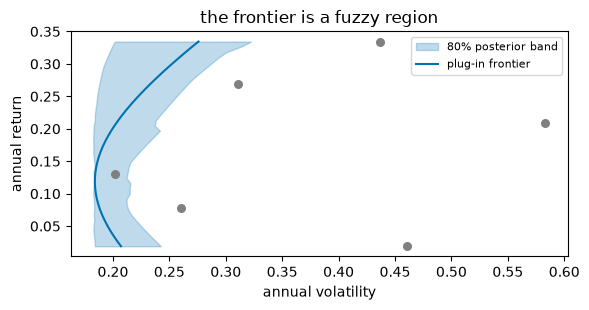

In [10]:
draws = post.sample(80)                                             # 80 (mu, Sigma) draws from the posterior
bands = []
for k in range(80):
    mk = draws['mean'][k] * ann; Sk = draws['cov'][k] * ann; ik = np.linalg.inv(Sk)
    ak, bk, ck = one @ ik @ one, one @ ik @ mk, mk @ ik @ mk; dk = ak * ck - bk ** 2
    bands.append([np.sqrt((lambda w: w @ Sk @ w)(ik @ (((ck - bk * m) / dk) * one + ((ak * m - bk) / dk) * mk))) for m in tgts])
bands = np.array(bands)
fig, ax = panel(1, 6, 3.2)
ax[0].fill_betweenx(tgts, np.percentile(bands, 10, 0), np.percentile(bands, 90, 0), color='#0072B2', alpha=0.25, label='80% posterior band')
ax[0].plot(fvol, tgts, color='#0072B2', label='plug-in frontier'); ax[0].scatter(sd, mu, c='gray', s=30)
ax[0].set(xlabel='annual volatility', ylabel='annual return', title='the frontier is a fuzzy region'); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Risk parity and the growth-optimal portfolio

Two allocation rules that sidestep the noisy means entirely. **Risk parity** equalises each asset's
contribution to portfolio variance (using the mixle-shrunk covariance), giving a balanced, low-turnover
portfolio. The **growth-optimal (Kelly)** portfolio maximises expected log-return -- the long-run
compounding rate -- and sits inside the frontier, trading a little Sharpe for geometric-growth optimality.

In [11]:
def risk_parity(S):
    def obj(w): rc = w * (S @ w); return np.sum((rc[:, None] - rc[None, :]) ** 2)
    return minimize(obj, one / N, bounds=[(1e-4, 1)] * N, constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}], method='SLSQP').x
w_rp = risk_parity(S_lw); rc = w_rp * (S_lw @ w_rp); rc /= rc.sum()
kel = minimize(lambda w: -np.mean(np.log1p(Asim @ w)), one / N, bounds=[(0, 1)] * N,
               constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}], method='SLSQP').x
print('risk-parity weights %s' % dict(zip(tickers, np.round(w_rp, 2))))
print('risk contributions equalised to ~1/N=%.2f: %s' % (1 / N, np.round(rc, 2)))
print('Kelly growth rate %.1f%%/yr vs tangency %.1f%%/yr' % (100 * np.mean(np.log1p(Asim @ kel)) * ann,
                                                             100 * np.mean(np.log1p(Asim @ np.clip(w_tan, 0, None) / np.clip(w_tan, 0, None).sum())) * ann))

risk-parity weights {'NORTHfield': np.float64(0.13), 'BANCOR': np.float64(0.22), 'PETRAX': np.float64(0.1), 'SHOPwell': np.float64(0.17), 'MEDIQ': np.float64(0.15), 'GRIDCO': np.float64(0.22)}
risk contributions equalised to ~1/N=0.17: [0.16 0.17 0.17 0.17 0.17 0.16]
Kelly growth rate 19.4%/yr vs tangency 21.7%/yr


## 11. A transaction-cost-aware backtest

The verdict is out-of-sample, net of trading costs. We walk forward, re-estimating each quarter and
charging for turnover, and compare strategies that differ only in their **return model**: the sample
covariance, the mixle **Ledoit-Wolf** covariance, risk parity, and 1/N. Shrinkage and risk parity trade
less and survive costs; the unshrunk optimiser churns and bleeds.

In [12]:
def backtest(weight_fn, cost_bps=10):
    win, step = 252, 63; pnl = []; w_prev = np.zeros(N); turn = 0.0
    for t in range(win, len(Asim) - step, step):
        w = weight_fn(Asim[t - win:t]); seg = Asim[t:t + step] @ w
        turn += np.abs(w - w_prev).sum(); pnl.append(seg - (np.abs(w - w_prev).sum() * cost_bps / 1e4) / step); w_prev = w
    p = np.concatenate(pnl); return p.mean() / p.std() * np.sqrt(ann), turn
def lw_cov(R): return np.asarray(estimate(rows(R), LedoitWolfEstimator(dim=N)).covar)
def samp_cov(R): return np.asarray(estimate(rows(R), MultivariateGaussianEstimator(dim=N)).covar)
strats = {'1/N': lambda R: one / N,
          'min-var (sample)': lambda R: np.clip(minvar(samp_cov(R)), -2, 2),
          'min-var (Ledoit-Wolf)': lambda R: (lambda w: w / w.sum())(np.clip(np.linalg.solve(lw_cov(R), one), 0, None) + 1e-9),
          'risk parity (LW)': lambda R: risk_parity(lw_cov(R))}
print('strategy                  net Sharpe   turnover')
for nm, fn in strats.items():
    s, t = backtest(fn); print('  %-22s %6.2f %10.1f' % (nm, s, t))

strategy                  net Sharpe   turnover
  1/N                      0.66        1.0
  min-var (sample)         0.74        5.3
  min-var (Ledoit-Wolf)    0.78        3.4
  risk parity (LW)         0.66        1.0


## In short

We made a probability model the centre of portfolio construction, with `mixle` carrying it end to
end:

* the joint **return distribution** fit as a Gaussian and a heavy-tailed **Student-t** (the fitted dof
  reads off the tail risk the Gaussian misses);
* covariance estimated with **Ledoit-Wolf shrinkage** -- a `LedoitWolfEstimator` added to the library in
  the course of this notebook -- which conditions the matrix and improves out-of-sample risk;
* **Bayesian returns** via a conjugate Normal-Inverse-Wishart posterior, with Black-Litterman as the
  views-driven special case and a posterior-predictive Student-t;
* **regimes** discovered with a mixture and tracked by posterior probability;
* **tail risk** (VaR/CVaR) computed by sampling the fitted model;
* **frontier uncertainty** propagated by sampling `(mu, Sigma)` from the posterior.

`scipy` did only the optimisation; every estimate it consumed came from a mixle model.

## A gap surfaced

Two capabilities a notebook like this wants are not yet in `mixle`, and are flagged for the library:
a **regime-switching (HMM) return model** (the `HiddenMarkovModelDistribution` with Gaussian emissions is
numerically fragile on heavy-tailed return scales -- it should fit a persistent-regime model here, but
currently the iid mixture above is the robust substitute), and a **GARCH / stochastic-volatility** family
for the volatility clustering. The Ledoit-Wolf estimator was the gap this notebook filled.

## References

* Markowitz, H. (1952). Portfolio selection. *Journal of Finance* 7(1).
* Ledoit, O., Wolf, M. (2004). A well-conditioned estimator for large-dimensional covariance matrices.
  *Journal of Multivariate Analysis* 88(2).
* Black, F., Litterman, R. (1992). Global portfolio optimization. *Financial Analysts Journal* 48(5).
* Rockafellar, R.T., Uryasev, S. (2000). Optimization of conditional value-at-risk. *Journal of Risk* 2.
* DeMiguel, V., Garlappi, L., Uppal, R. (2009). Optimal versus naive diversification. *RFS* 22(5).

## Exercises and extensions

1. **Robust frontier.** Choose weights that maximise the *worst-case* Sharpe over the posterior `(mu,
   Sigma)` draws, and compare turnover to the plug-in tangency portfolio.
2. **Heavy-tailed risk parity.** Replace the covariance in risk parity with the Student-t scale matrix and
   re-evaluate the crisis drawdown.
3. **Regime-aware allocation.** Use the mixture's posterior crisis probability to scale exposure, and
   backtest the timing rule net of costs.
4. **Fix the HMM gap.** Make `HiddenMarkovModelDistribution` numerically robust on return-scale data
   (emission covariance flooring) and fit a true regime-switching model.
5. **Add a GARCH family.** Implement a conditional-volatility distribution in `mixle` and use it for
   the VaR forecast.